In [1]:
import pandas as pd

game = pd.read_csv("game.csv")




# Convertir correctamente la fecha (día primero)
game['game_date'] = pd.to_datetime(game['game_date'], dayfirst=True, errors='coerce')

# Filtrar solo partidos desde el 31/12/1999 en adelante
game = game[game['game_date'] >= '1999-12-31'].reset_index(drop=True)

# Crear columna target home_win
game['home_win'] = (game['pts_home'] > game['pts_away']).astype(int)

# Verifica que se cargaron bien
print(game[['game_date', 'pts_home', 'pts_away', 'home_win']].head())



# Selección de features
features = [
    "fg_pct_home", "fg_pct_away",
    "fg3_pct_home", "fg3_pct_away",
    "ft_pct_home", "ft_pct_away",
    "reb_home", "reb_away",
    "ast_home", "ast_away",
    "stl_home", "stl_away",
    "blk_home", "blk_away",
    "tov_home", "tov_away"
]

X = game[features]
y = game["home_win"]

print("Shape:", X.shape)


   game_date  pts_home  pts_away  home_win
0 2000-01-02       111     103.0         1
1 2000-01-03       106     118.0         0
2 2000-01-03        99      87.0         1
3 2000-01-03       109      89.0         1
4 2000-01-03        63      88.0         0
Shape: (33678, 16)


Train/test

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


Entrenar el modelo 

In [3]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=450,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=450,
              n_jobs=None, num_parallel_tree=None, ...)

Evaluar el modelo

In [4]:
from sklearn.metrics import accuracy_score, classification_report

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.8959323040380047
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2794
           1       0.90      0.92      0.91      3942

    accuracy                           0.90      6736
   macro avg       0.89      0.89      0.89      6736
weighted avg       0.90      0.90      0.90      6736



Featur Importance

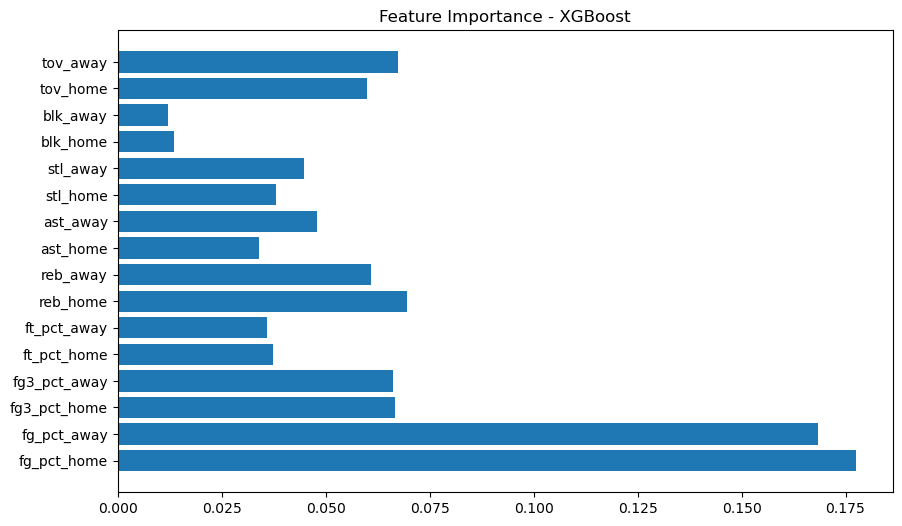

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance - XGBoost")
plt.show()


Matriz de Confusión

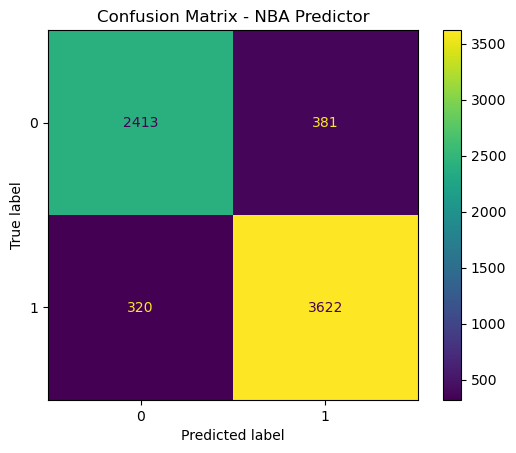

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.title("Confusion Matrix - NBA Predictor")
plt.show()


Predecir un partido especifico

In [7]:
import numpy as np

sample_game = np.array([[
    0.47, 0.44,   # FG%
    0.37, 0.33,   # FG3%
    0.80, 0.78,   # FT%
    44, 40,       # Reb
    26, 22,       # Ast
    7, 5,         # Stl
    5, 4,         # Blk
    13, 15        # TOV
]])

pred = model.predict(sample_game)[0]
print("Ganador:", "Home" if pred == 1 else "Away")


Ganador: Home


In [8]:
import numpy as np

# Orlando Magic (HOME) vs LA Clippers (AWAY)

new_game = np.array([[
    # FG%
    0.471, 0.468,
    # 3PT%
    0.346, 0.361,
    # FT%
    0.804, 0.831,
    # REB
    45.3, 41.5,
    # AST
    24.9, 23.7,
    # STL
    8.5, 8.6,
    # BLK
    5.5, 5.3,
    # TOV
    15.5, 16.5
]])

pred = model.predict(new_game)[0]
proba = model.predict_proba(new_game)[0]

print("Predicted Winner:", "ORLANDO MAGIC (HOME)" if pred == 1 else "LA CLIPPERS (AWAY)")
print("Probabilidad HOME:", proba[1])
print("Probabilidad AWAY:", proba[0])

Predicted Winner: ORLANDO MAGIC (HOME)
Probabilidad HOME: 0.760491
Probabilidad AWAY: 0.23950899


In [9]:
import pandas as pd
import itertools

# =========================
# Load team stats (PER GAME)
# =========================
teams = pd.read_csv("nba_team_stats_per_game.csv")

# Normalizar nombres de columnas (por seguridad)
teams.columns = teams.columns.str.lower()

# =========================
# Column mapping (team stats → model features)
# =========================
feature_map = {
    "fg_pct": "fg_pct",
    "fg3_pct": "fg3_pct",
    "ft_pct": "ft_pct",
    "reb": "reb",
    "ast": "ast",
    "stl": "stl",
    "blk": "blk",
    "tov": "tov"
}

# =========================
# Generate ALL matchups
# (home vs away, excluding same team)
# =========================
matchups = []

for home, away in itertools.permutations(teams.itertuples(index=False), 2):
    if home.team_id == away.team_id:
        continue

    row = {
        "home_team": home.team_name,
        "away_team": away.team_name,
    }

    # Build features exactly as training set
    for feat in feature_map:
        row[f"{feat}_home"] = getattr(home, feat)
        row[f"{feat}_away"] = getattr(away, feat)

    matchups.append(row)

df_matchups = pd.DataFrame(matchups)

print("Total matchups generated:", len(df_matchups))

# =========================
# Feature matrix (same order as training)
# =========================
features = [
    "fg_pct_home", "fg_pct_away",
    "fg3_pct_home", "fg3_pct_away",
    "ft_pct_home", "ft_pct_away",
    "reb_home", "reb_away",
    "ast_home", "ast_away",
    "stl_home", "stl_away",
    "blk_home", "blk_away",
    "tov_home", "tov_away"
]

X_pred = df_matchups[features]

# =========================
# Predict
# =========================
df_matchups["home_win_pred"] = model.predict(X_pred)
proba = model.predict_proba(X_pred)

df_matchups["home_win_prob"] = proba[:, 1]
df_matchups["away_win_prob"] = proba[:, 0]

# Winner label
df_matchups["predicted_winner"] = df_matchups.apply(
    lambda x: x["home_team"] if x["home_win_pred"] == 1 else x["away_team"],
    axis=1
)

# =========================
# Sort by confidence
# =========================
df_matchups = df_matchups.sort_values("home_win_prob", ascending=False)

# =========================
# Export
# =========================
df_matchups.to_csv("nba_all_matchups_predictions.csv", index=False)

print("✅ File generated: nba_all_matchups_predictions.csv")


Total matchups generated: 870
✅ File generated: nba_all_matchups_predictions.csv
